## Group of stim-phase effects of gradient features

#### Statistics
- state/trait effects of whole-gradient/NPC-dispersion on beta-GMs (whole timeseries NPD-dispersion from different script)
    - catplots as overview of trends
    - statistics: 
        - single Tests (state/trait effect) test for normally first
        - both at same time: mixed ANOVA --> what I ultimately reported in OHBM abstract
- Relation of NPC dispersion and NPC-network-composition:
    - covariance matrix

#### Visualization 
- visualization with group average gradients
    - NPC dispersion (distance to centroid) (control/DD)
    - principal gradient dipsersion (stim1/2)
- visualization pf PFM group differences but plotting exampkle representitive subject for each group (high/low NPCdispersion/visual2 count)
    - sub-01 for control & sub-45 for DD (PFMs look mostly similar, only strong difference in NPC - by visual2 extension!)

#### OLD
tried differnt ways to visualize NPC dispersion (whole timeseries, )


In [1]:

import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import normaltest, ttest_ind, mannwhitneyu, ttest_rel

from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()
N_vertices = len(np.where(mask==True)[0])

dataset ='dnumrisk' #'smile1'#
bids_folder = f'/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-{dataset}'
subList = [f'{int(sub):02d}' for sub in range(1, 67)]
group_list =  pd.read_csv(op.join(bids_folder, 'group_mapping.csv'), header=0, index_col=0)

source_folder_betaGMs = op.join(bids_folder,'derivatives','gradients.glmsingle')

In [121]:
n_gradients = 2 
derivative_obj_name = 'g-aligned'

dfs = []
mask, _ = get_basic_mask()
for n_stim in [1,2]:
    gms = {f'g{i+1}': [] for i in range(n_gradients)}
    
    sub_array = []
    for sub in subList:
            source_folder_gm =  op.join(source_folder_betaGMs,f'sub-{sub}')
            fn = op.join(source_folder_gm,f'sub-{sub}_g-aligned_space-fsaverag5_n10_stimulus-{n_stim}_betas_kernel-normalized_angle.npy')
            if not op.exists(fn):
                print(f'File not found: {fn}')
                continue
            gm = np.load(fn)
            for i in range(n_gradients):
                gms[f'g{i+1}'].append(gm[i, mask])
            sub_array.append(int(sub))

    for i in range(n_gradients):
        gradient_df = pd.DataFrame(gms[f'g{i+1}'], index=sub_array)
        gradient_df.index.name = 'subject'
        gradient_df['n_gradient'] = i + 1
        gradient_df = gradient_df.set_index('n_gradient', append=True)
        gradient_df['stim'] = n_stim
        gradient_df = gradient_df.set_index('stim', append=True)
        dfs.append(gradient_df)

df_gms_stimuli = pd.concat(dfs).sort_index()    # final multi-index dataframe



File not found: /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients.glmsingle/sub-03/sub-03_g-aligned_space-fsaverag5_n10_stimulus-1_betas_kernel-normalized_angle.npy


In [7]:
df_gm_std_stimuli = pd.DataFrame(df_gms_stimuli.std(axis=1), columns=['std'])
df_gm_std_stimuli = df_gm_std_stimuli.join(group_list, on='subject')

# ANOVA
y_var = 'std'
for n_grad in [1,2]:
    tmp = df_gm_std_stimuli.xs(n_grad, level='n_gradient')
    valid_subjects = (tmp.reset_index().groupby('subject')['stim'].nunique().pipe(lambda s: s[s==2].index))
    tmp_clean = tmp.loc[tmp.index.get_level_values('subject').isin(valid_subjects)]

    df_long = tmp_clean.reset_index()[['subject','group','stim', y_var]]
    df_long.rename(columns={y_var: 'value'}, inplace=True)

    import pingouin as pg

    anova = pg.mixed_anova(data=df_long,
                dv='value',
                within='stim',
                between='group',
                subject='subject')
    print(f'Beta Grad-{n_grad} dispersion ANOVA results:\n \n', anova)



Beta Grad-1 dispersion ANOVA results:
 
         Source        SS  DF1  DF2        MS          F         p-unc  \
0        group  0.000026    1   63  0.000026   0.254846  6.154447e-01   
1         stim  0.000518    1   63  0.000518  41.302856  1.972115e-08   
2  Interaction  0.000041    1   63  0.000041   3.257193  7.589030e-02   

        np2  eps  
0  0.004029  NaN  
1  0.395990  1.0  
2  0.049160  NaN  
Beta Grad-2 dispersion ANOVA results:
 
         Source            SS  DF1  DF2            MS         F     p-unc  \
0        group  4.147535e-04    1   63  4.147535e-04  5.591770  0.021139   
1         stim  2.853623e-06    1   63  2.853623e-06  0.258027  0.613253   
2  Interaction  6.293273e-07    1   63  6.293273e-07  0.056904  0.812232   

        np2  eps  
0  0.081522  NaN  
1  0.004079  1.0  
2  0.000902  NaN  


## NPC dispersion

In [5]:
def get_NPC_mask(bids_folder_orig = '/mnt_03/ds-dnumrisk', space = 'fsaverage5'):
    surf_mask_L = op.join(bids_folder_orig, 'derivatives/surface_masks', f'desc-NPC_L_space-{space}_hemi-lh.label.gii')
    surf_mask_L = nib.load(surf_mask_L).agg_data()
    surf_mask_R = op.join(bids_folder_orig, 'derivatives/surface_masks', f'desc-NPC_R_space-{space}_hemi-rh.label.gii')
    surf_mask_R = nib.load(surf_mask_R).agg_data()
    nprf_r2 = np.concatenate((surf_mask_L, surf_mask_R))

    nprf_r2 = np.bool_(nprf_r2)
    return nprf_r2

nprf_r2 = get_NPC_mask()
mask, labeling_noParcel = get_basic_mask()

np.shape(nprf_r2)

(20484,)

In [191]:
# dispersion measures
df_onlyNPC = df_gms_stimuli[np.where(nprf_r2[mask])[0]]
df_onlyNPC_means = pd.DataFrame(df_onlyNPC.mean(axis=1), columns=['mean'])
df_onlyNPC_centered_squared = df_onlyNPC.sub(df_onlyNPC_means['mean'], axis=0)**2
df_npc_dispersion_2d = (df_onlyNPC_centered_squared.xs(1, level='n_gradient') +df_onlyNPC_centered_squared.xs(2, level='n_gradient')).mean(axis=1).to_frame(name='NPC_dispersion_2D').join(group_list, on='subject')

# ANOVA
y_var = 'NPC_dispersion_2D'
n_grad = 'both-2D'

tmp = df_npc_dispersion_2d.copy()
valid_subjects = (tmp.reset_index().groupby('subject')['stim'].nunique().pipe(lambda s: s[s==2].index))
tmp_clean = tmp.loc[tmp.index.get_level_values('subject').isin(valid_subjects)]

df_long = tmp_clean.reset_index()[['subject','group','stim', y_var]]
df_long.rename(columns={y_var: 'value'}, inplace=True)

import pingouin as pg

anova = pg.mixed_anova(data=df_long,
            dv='value',
            within='stim',
            between='group',
            subject='subject')
print(f'Beta Grad-{n_grad} NPC dispersion ANOVA results:\n', anova)



Beta Grad-both-2D NPC dispersion ANOVA results:
         Source            SS  DF1  DF2            MS         F     p-unc  \
0        group  6.827700e-06    1   63  6.827700e-06  4.747783  0.033084   
1         stim  1.471018e-07    1   63  1.471018e-07  0.869101  0.354763   
2  Interaction  9.683277e-08    1   63  9.683277e-08  0.572104  0.452243   

        np2  eps  
0  0.070080  NaN  
1  0.013608  1.0  
2  0.008999  NaN  


# Precision Functional Mapping

dataframe with N-vertices count for each network (columns - 1-9) for each sub (rows)

In [4]:
net_folder = op.join(bids_folder, 'derivatives', 'networks_infomap_full_01')

from numrisk.fmri_analysis.gradients.utils import get_glasser_parcels, get_glasser_CAatlas_mapping
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

df_nets_counts = pd.DataFrame(columns=[f'net_{x}' for x in range(2, 10)], index=range(1, 67), dtype=float)
df_nets_counts.index.name = 'subject'
df_nets_counts = df_nets_counts.join(group_list).set_index(['group'], append=True)

only_NPC = True
npc_mask = nprf_r2
hemi = 'both'

for sub in subList:
    try:
        nets = np.load(op.join(net_folder, f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter.npy'))
        if only_NPC:
            nets_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
            nets_fsav5[mask] = nets
            nets = nets_fsav5[npc_mask]
        net_i, counts = np.unique(nets, return_counts=True)

        for net, count in zip(net_i, counts):
            df_nets_counts.loc[int(sub), f'net_{int(net)}'] = count

    except Exception as e:
        print(f'Error processing sub-{sub}: {e}')

#df_nets_counts['net_7+9'] = df_nets_counts['net_7'].fillna(0) + df_nets_counts['net_9'].fillna(0) # fronto-parietal & default-mode together!
df_nets_counts.drop('net_-1', axis=1, inplace=True)

Error processing sub-02: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/networks_infomap_full_01/sub-02_consensusMapping_confspec-36Pscrub3BPfilter.npy'


In [ ]:
# between group test:
from scipy.stats import ttest_ind, mannwhitneyu, normaltest
alpha = 0.05

for i, net in enumerate(df_nets_counts.columns[:9]):
    # Convert to numeric and drop NaNs manually
    group0_data = df_nets_counts.xs(0,0,'group')[net].dropna()
    group1_data = df_nets_counts.xs(1,0,'group')[net].dropna()
    net_name =  CAatlas_names.loc[int(net[4])]['Network Name']

    try:
        numeric_data = df_nets_counts[net].dropna()
        _, pval_normal = normaltest(numeric_data)

        if pval_normal > alpha:
            stats = ttest_ind(group0_data, group1_data)
            test_type = 'T'
        else:
            stats = mannwhitneyu(group0_data, group1_data)   
            test_type = 'MWU'  
        print(f'\n' + net_name)
        print(stats)

    except:
        print()


Visual2
MannwhitneyuResult(statistic=376.0, pvalue=0.04681071230576116)

Somatomotor
MannwhitneyuResult(statistic=562.5, pvalue=0.6554826318904325)

Cingulo-Opercular
MannwhitneyuResult(statistic=414.5, pvalue=0.3563733943181082)

Dorsal-attention
MannwhitneyuResult(statistic=659.5, pvalue=0.08562042178882498)


Frontoparietal
MannwhitneyuResult(statistic=97.5, pvalue=0.7793921950265136)

Auditory
MannwhitneyuResult(statistic=91.5, pvalue=0.038288281887716574)

Default
MannwhitneyuResult(statistic=468.5, pvalue=0.5634543783578477)


## Relation of NPC dispersion and network-composition

In [10]:
df_npcDisp_wholeTS = pd.read_csv(op.join('/mnt_03/ds-dnumrisk', 'derivatives','phenotype', 'withinNdispersion-NPC_grad-2_confspec-36Pscrub3BPfilterrunFD104.csv')).set_index('subject')
df_comb = df_nets_counts.join(df_npcDisp_wholeTS, on='subject').drop('group', axis=1)

df_comb = df_comb.drop('net_6', axis=1).drop('net_8', axis=1) # auditory and language

<Axes: >

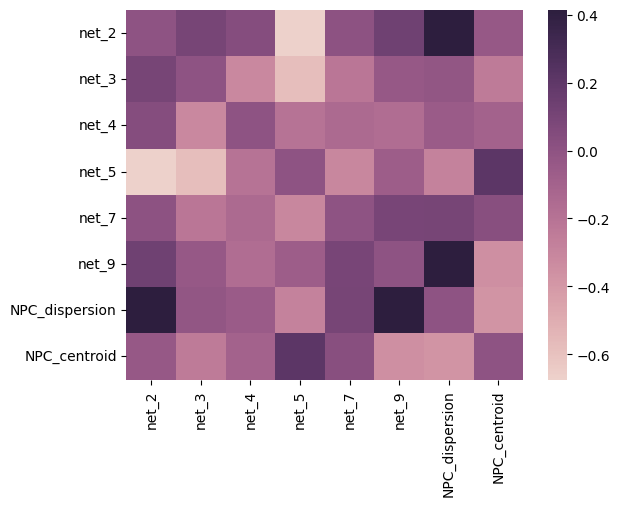

In [11]:
corrs = df_comb.corr()

for i in corrs.index:
    corrs.loc[i, i] = 0
    
sns.heatmap(corrs,cmap=sns.cubehelix_palette(as_cmap=True) )

In [101]:
# proper statistics 

from scipy.stats import pearsonr

for net in [f'net_{n}' for n in [2,5,9]]:
    tmp = df_comb[['NPC_dispersion', net]].dropna()
    print(net)
    print(pearsonr(tmp['NPC_dispersion'],tmp[net] ))

net_2
PearsonRResult(statistic=0.41382305536018643, pvalue=0.0006761184779172328)
net_5
PearsonRResult(statistic=-0.2866240880209631, pvalue=0.021664056216996422)
net_9
PearsonRResult(statistic=0.41034108795865426, pvalue=0.0008372634291396025)


## Visualization

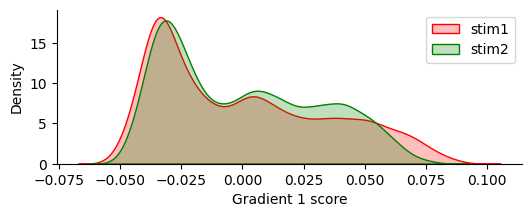

In [186]:
tmp = df_gms_stimuli.xs(1,0,'n_gradient').groupby('stim').mean()

fig, axes = plt.subplots(1, 1,figsize = (6,2))
sns.kdeplot(tmp.iloc[0], label='stim1',fill=True,ax=axes, color='red')
sns.kdeplot(tmp.iloc[1], label='stim2',ax=axes,fill=True, color='green')
sns.despine()
axes.set(xlabel='Gradient 1 score') #, xticklabels='')
plt.legend()

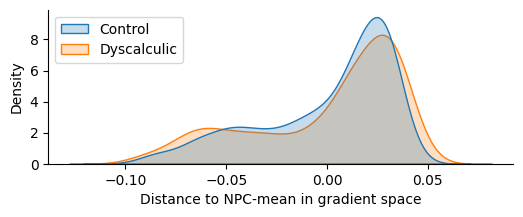

In [211]:
df_onlyNPC = df_gms_stimuli[np.where(nprf_r2[mask])[0]]
df_onlyNPC_means = pd.DataFrame(df_onlyNPC.mean(axis=1), columns=['mean'])
df_onlyNPC_centered = df_onlyNPC.sub(df_onlyNPC_means['mean'], axis=0)#**2
df_onlyNPC_distance_2d = df_onlyNPC_centered.xs(1, level='n_gradient') + df_onlyNPC_centered.xs(2, level='n_gradient')#.to_frame(name='NPC_dispersion_2D')

df_onlyNPC_distance_2d = df_onlyNPC_distance_2d.join(group_list, on='subject')
df_onlyNPC_distance_2d['group'] = df_onlyNPC_distance_2d['group'].map({ 0: 'Control',1: 'Dyscalculic'})
group_NPC_distance_2d = df_onlyNPC_distance_2d.groupby('group').mean().T.stack('group').reset_index('group')

fig, axes = plt.subplots(1, 1,figsize = (6,2))
sns.kdeplot(group_NPC_distance_2d, x=0,hue='group', fill=True, ax=axes)
axes.set(xlabel='Distance to NPC-mean in gradient space') #, xticklabels='')
sns.despine()
leg = axes.get_legend()
leg.set_title(None)

In [ ]:
## Check which subject are representitive for each group (high/low NPCdispersion/visual2 count)
df_comb.sort_values('NPC_dispersion')

,,net_2,net_3,net_4,net_5,net_7,net_9,NPC_dispersion,NPC_centroid
subject,group,,,,,,,,
1,0,64.0,97.0,29.0,1239.0,58.0,23.0,1.891885,2.003238
66,0,36.0,129.0,NaN,1175.0,145.0,23.0,1.942982,0.517751
63,0,86.0,405.0,189.0,810.0,NaN,20.0,2.061156,-0.136145
28,0,67.0,217.0,31.0,1163.0,NaN,29.0,2.167430,0.412419
12,0,74.0,173.0,97.0,1150.0,NaN,16.0,2.270525,1.000305
...,...,...,...,...,...,...,...,...,...
40,1,318.0,64.0,259.0,845.0,NaN,22.0,18.647175,-0.498796
45,1,390.0,225.0,40.0,730.0,94.0,31.0,20.902368,0.967081
27,1,372.0,73.0,55.0,577.0,387.0,46.0,22.156896,0.154561


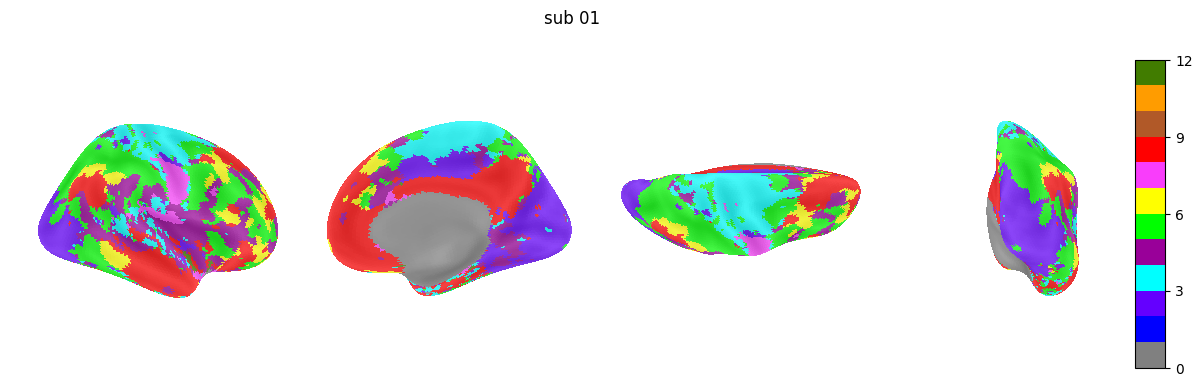

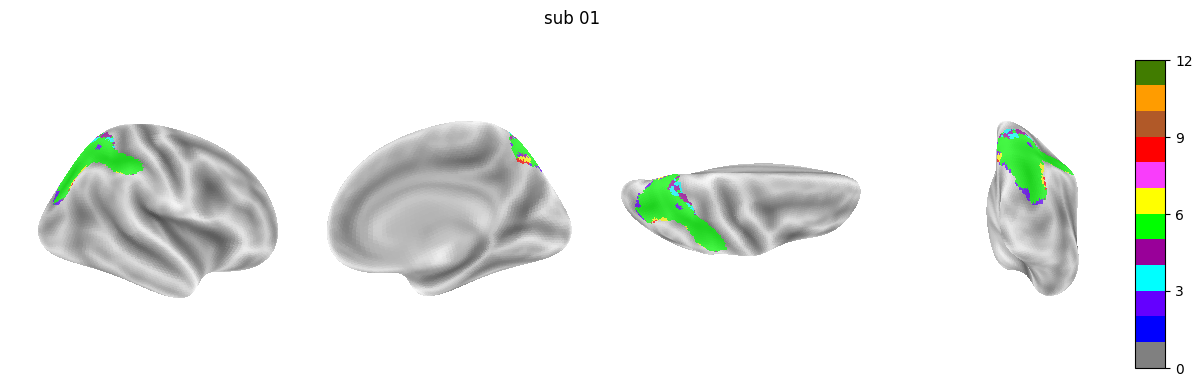

In [6]:
from networks_indTopology.utils import plot_nets_CAcolors
from gradients_noHalo.utils import get_basic_mask

sub = '01'
net_folder = op.join(bids_folder, 'derivatives', 'networks_infomap_full_01')

fn_pfm = op.join(net_folder, f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter.npy')
pfmap = np.load(fn_pfm)

mask, _ = get_basic_mask()
map_fsav5 = np.zeros(mask.shape)
map_fsav5[mask] = pfmap

fig = plot_nets_CAcolors(map_fsav5)
fig.suptitle(f'sub {sub}', y=0.75)

map_fsav5[~nprf_r2] = np.nan
fig = plot_nets_CAcolors(map_fsav5)
fig.suptitle(f'sub {sub}', y=0.75)

plt.show()

In [ ]:
# cleaned version (removed small pieces)
sub = '45'
net_folder = op.join(bids_folder, 'derivatives', 'networks_infomap_full_01')
plot_folder = op.join(bids_folder,'plots_and_ims','networks_infomap_full_cleaned')

fn_pfm = op.join(net_folder, f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter_cleaned_fsaverage5.npy')
pfmap = np.load(fn_pfm)

map_fsav5= pfmap

fig = plot_nets_CAcolors(map_fsav5)
fig.suptitle(f'sub {sub}', y=0.75)

map_fsav5[~nprf_r2] = np.nan
fig = plot_nets_CAcolors(map_fsav5)
fig.suptitle(f'sub {sub}', y=0.75)
plot_fn = op.join(plot_folder, f'sub-{sub}_ses-1_task-magjudge_networks_infomap_hemi-R_confspec-36Pscrub3BPfilter_cleaned_onlyNPC.png')
fig.savefig(plot_fn, dpi=300, bbox_inches='tight')

## OLD

In [161]:
n_gradients = 2
aligned = True # False only for eccentricity or 2D dispersion?
alignRef = 'tanH'
kernel ='normalized_angle' #  None #
ztransf = True #'True_ccfilter'
specification = f'kernel-{kernel}_ztransf-{ztransf}'
source_folder = op.join(bids_folder,'derivatives','gradients.tryParams.36P')

import glob
n_gradients = 3
gms = {f'g{i+1}': [] for i in range(n_gradients)}
for sub in subList:
    source_folder_gm =  op.join(source_folder,f'sub-{sub}')
    sub_file_pattern = op.join(source_folder_gm,f'sub-{sub}_g-aligned-{alignRef}_{specification}*.npy') if aligned else op.join(source_folder_gm,f'sub-{sub}_gradients_{specification}*.npy')
    fn = glob.glob(sub_file_pattern)[0]
    gm= np.load(fn)
    for i in range(n_gradients):
        gms[f'g{i+1}'].append(gm[i, :])

sub_array = np.array([int(i) for i in subList])
dfs = []
for i in range(n_gradients):
    gradient_df = pd.DataFrame(gms[f'g{i+1}'], index=sub_array)
    gradient_df.index.name = 'subject'
    gradient_df = gradient_df.join(group_list).set_index('group', append=True)
    gradient_df['n_gradient'] = i + 1
    dfs.append(gradient_df.set_index('n_gradient', append=True))

df_gms = pd.concat(dfs).sort_index(level='n_gradient')

In [159]:
source_folder_gm

'/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients.36Pscrub3BPfilterrunFD104/sub-66'

In [ ]:
df_onlyNPC = pd.DataFrame(df_gms[np.where(nprf_r2[mask])[0]])
df_onlyNPC_centered_squared = df_onlyNPC.sub(df_onlyNPC_means['mean'], axis=0)**2
df_onlyNPC_distance_2d = (df_onlyNPC_centered_squared.xs(1, level='n_gradient') +df_onlyNPC_centered_squared.xs(2, level='n_gradient')).join(group_list, on='subject').set_index('group',append=True)



Text(0.5, 1.0, 'group average NPC-vertices')

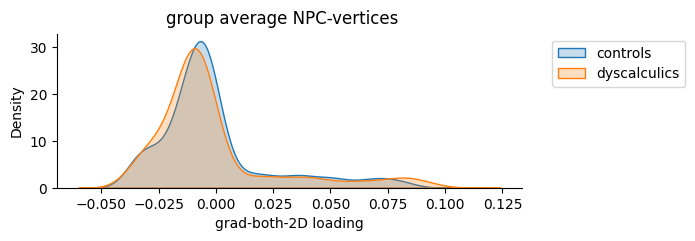

In [187]:
n_gradient = 2
tmp = df_onlyNPC.xs(n_gradient,0,'n_gradient')
fig, axes = plt.subplots(1, 1,figsize = (6,2))
sns.kdeplot(tmp.xs(0, level='group').mean(axis=0), label='controls',fill=True,ax=axes)
sns.kdeplot(tmp.xs(1, level='group').mean(axis=0), label='dyscalculics',ax=axes,fill=True)
sns.despine()
axes.set(xlabel=f'grad-{n_grad} loading')
axes.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
fig.suptitle(f'group average NPC-vertices',y=1.)

<Axes: xlabel='0', ylabel='Density'>

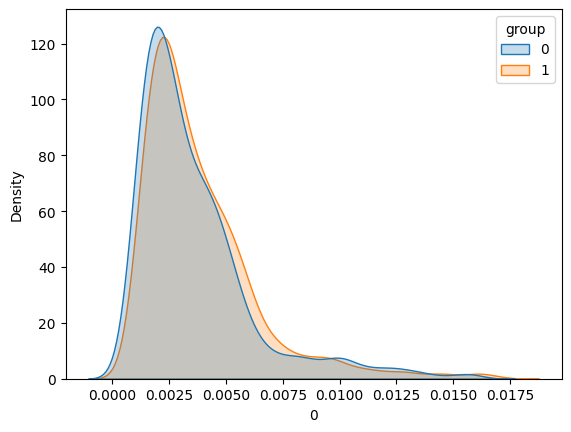

In [108]:
grad_group0 = np.load(op.join(bids_folder, 'derivatives' , 'gradients.36Pscrub3runFD104', 'sub-group0','sub-group0_g-aligned-tanH_kernel-normalized_angle_ztransf-True.npy'))
grad_group1 = np.load(op.join(bids_folder, 'derivatives' , 'gradients.36Pscrub3runFD104', 'sub-group1','sub-group1_g-aligned-tanH_kernel-normalized_angle_ztransf-True.npy'))

npc_mask = nprf_r2

df_grad_npc = pd.DataFrame

In [ ]:
df_npc = pd.DataFrame(
df_onlyNPC_means = pd.DataFrame(df_onlyNPC.mean(axis=1), columns=['mean'])
df_onlyNPC_centered_squared = df_onlyNPC.sub(df_onlyNPC_means['mean'], axis=0)**2
df_npc_dispersion_2d = (df_onlyNPC_centered_squared.xs(1, level='n_gradient') +df_onlyNPC_centered_squared.xs(2, level='n_gradient')).mean(axis=1).to_frame(name='NPC_dispersion_2D').join(group_list, on='subject')


In [110]:
grad_group0.shape

(10, 20484)

<Axes: ylabel='Density'>

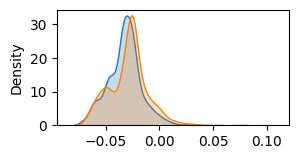

In [120]:
n_grad = 0
fig, ax = plt.subplots(1,1, figsize=(3,1.5))
sns.kdeplot(grad_group0[n_grad,npc_mask], fill=True, ax=ax)
sns.kdeplot(grad_group1[n_grad,npc_mask], fill=True, ax=ax)


In [ ]:
# between group test:
from scipy.stats import ttest_ind, mannwhitneyu, normaltest
alpha = 0.05

figure, axes = plt.subplots(3, 3, figsize=(7,7))
axs = axes.flatten()
for i, net in enumerate(df_nets_counts.columns[:9]):
    sns.barplot(data=df_nets_counts.reset_index(), x='group', hue='group', y=net, alpha=0.5, legend=False, ax=axs[i])
    sns.swarmplot(data=df_nets_counts.reset_index(), x='group', hue='group', y=net, size=4, legend=False, ax=axs[i])
    
    # Convert to numeric and drop NaNs manually
    group0_data = df_nets_counts.xs(0,0,'group')[net].dropna()
    group1_data = df_nets_counts.xs(1,0,'group')[net].dropna()

    try:
        numeric_data = df_nets_counts[net].dropna()
        _, pval_normal = normaltest(numeric_data)

        if pval_normal > alpha:
            stats = ttest_ind(group0_data, group1_data)
            test_type = 'T'
        else:
            stats = mannwhitneyu(group0_data, group1_data)   
            test_type = 'MWU'
        net_name =  CAatlas_names.loc[int(net[4])]['Network Name']
        axs[i].set(xlabel=None, title=f'{net_name} \n p({test_type})={stats.pvalue:.3f}') # CAatlas_names.loc[n_network]['Network Name']


    except:
        print(f'Normality test failed for {net}, defaulting to t-test')
        axs[i].set(xlabel=None, title=f'{net} \n p=NaN')

plt.subplots_adjust(hspace=0.5,wspace=0.5)
sns.despine()
figure.suptitle(f'Group comparison: Network sizes \n NPC mask - {only_NPC}, hemi-{hemi}', y=1.02)